# 06+07 Combined — Semantic distance + Human vs AI comparison

**Run this notebook on JupyterHub (H100) and go to sleep.**
It produces figures 05 and 07, plus the summary table, all in one pass.

What it does:
1. Fixes the sentence-transformers / typing_extensions conflict
2. Checks GPU and reinstalls torch for CUDA 12.4 if needed
3. Computes cosine(post, human TL;DR) and cosine(post, AI summary) per post
4. Computes first-person density, surface flags, keyword containment
5. Figure 05: containment vs cosine scatter map (human vs AI reference)
6. Figure 07: human vs AI comparison bars per community
7. Saves everything and copies figures to the website folder

Only the 1,800 AI-summarized posts are used for both figures.
That is enough for a robust comparison and runs in under 2 min on H100.

## Cell 1 — Fix environment

The `typing_extensions` version on JupyterHub conflicts with sentence-transformers.
We also reinstall torch for CUDA 12.4 as the cheat sheet says.

In [1]:
import subprocess, sys

def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

print("Upgrading typing_extensions (fixes sentence-transformers import error)…")
_pip("--upgrade", "typing_extensions")

print("Installing/upgrading sentence-transformers…")
_pip("--upgrade", "sentence-transformers")

print("Ensuring other deps…")
_pip("pandas", "pyarrow", "matplotlib", "scikit-learn", "pyyaml")

print("All deps installed.")

Upgrading typing_extensions (fixes sentence-transformers import error)…
Installing/upgrading sentence-transformers…
Ensuring other deps…
All deps installed.


## Cell 2 — GPU check + reinstall torch for CUDA 12.4 if needed

(This is the JupyterHub cheat-sheet step.)

In [2]:
import importlib, torch as _torch_pre
_cuda_ok = _torch_pre.cuda.is_available()
print(f"torch {_torch_pre.__version__}  CUDA available: {_cuda_ok}")
if _cuda_ok:
    print(f"GPU: {_torch_pre.cuda.get_device_name(0)}")

if not _cuda_ok:
    print("CUDA not visible — reinstalling torch for cu124…")
    _pip("--force-reinstall", "torch", "torchvision",
         "--index-url", "https://download.pytorch.org/whl/cu124")
    # reload
    import importlib
    import torch
    print(f"After reinstall: CUDA={torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {DEVICE}")

torch 2.6.0+cu124  CUDA available: True
GPU: NVIDIA H100 80GB HBM3

Using device: cuda


## Cell 3 — Root detection + imports

In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up until we find the src/tldr_audit package
def _find_root() -> Path:
    if "__file__" in dir():
        return Path(__file__).resolve().parents[1]
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / "src" / "tldr_audit").exists():
            return p
    raise RuntimeError("Cannot find project root. Run from code/ directory.")

ROOT = _find_root()
print("ROOT:", ROOT)

sys.path.insert(0, str(ROOT / "src"))
from tldr_audit.features import (  # noqa: E402
    features_for_post, keyword_containment, summary_novelty
)

FIG  = ROOT / "results" / "figures"
TAB  = ROOT / "results" / "tables"
WEB  = ROOT.parent / "figures"    # website folder (document_analysis_project/figures/)
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)
WEB.mkdir(parents=True, exist_ok=True)

COLORS_BUCKET = {
    "political":    "#D55E00",
    "mental_health":"#0072B2",
    "advice":       "#009E73",
}
COLORS_SRC = {"human": "#333333", "ai": "#D55E00"}
BUCKET_LABEL = {
    "political":    "Political",
    "mental_health":"Mental-health",
    "advice":       "Advice",
}

ROOT: /home/jovyan/document_analysis_project/code


## Cell 4 — Load data

We load ONLY the 1,800 AI-summarised posts.
`sample.jsonl` is used as a lookup for bucket / subreddit in case
`ai_summaries.jsonl` is missing those fields.

In [4]:
sample_path = ROOT / "data" / "interim" / "sample.jsonl"
ai_path     = ROOT / "data" / "interim" / "ai_summaries.jsonl"

if not sample_path.exists():
    raise FileNotFoundError(f"sample.jsonl not found at {sample_path}")
if not ai_path.exists():
    raise FileNotFoundError(
        f"ai_summaries.jsonl not found at {ai_path}\n"
        "Upload it from your local machine:\n"
        "  scp data/interim/ai_summaries.jsonl jovyan@<hub>:~/document_analysis_project/code/data/interim/"
    )

posts_lookup = {json.loads(l)["id"]: json.loads(l)
                for l in open(sample_path, encoding="utf-8")}
ai_records   = [json.loads(l) for l in open(ai_path, encoding="utf-8")]

print(f"Loaded {len(posts_lookup):,} posts (lookup) and {len(ai_records):,} AI records")

# Build a flat DataFrame for the 1,800 posts
rows = []
for a in ai_records:
    pid  = a["id"]
    src  = posts_lookup.get(pid, {})
    rows.append({
        "id":        pid,
        "subreddit": a.get("subreddit") or src.get("subreddit"),
        "bucket":    a.get("_bucket")   or src.get("_bucket"),
        "content":   a.get("content")   or src.get("content") or "",
        "human":     a.get("human_tldr")or src.get("summary") or "",
        "ai":        a.get("summary")   or "",
    })

df = pd.DataFrame(rows)
df = df[df["content"].str.strip().astype(bool)]   # drop empty posts
print(f"Working set: {len(df):,} posts across {df['subreddit'].nunique()} subreddits")
print(df.groupby(["bucket","subreddit"]).size().to_string())

Loaded 39,859 posts (lookup) and 1,800 AI records
Working set: 1,800 posts across 9 subreddits
bucket         subreddit          
advice         legaladvice            200
               personalfinance        200
               relationships          200
mental_health  Anxiety                200
               depression             200
               offmychest             200
political      PoliticalDiscussion    200
               politics               200
               worldnews              200


## Cell 5 — Semantic cosine (GPU SBERT)

ELI5: we turn each text into a 768-number "meaning vector", then measure
the angle between the post vector and the TL;DR vector.
Angle ≈ 0° (cosine ≈ 1) → same meaning. Angle large → different meaning.

On H100 this takes ~10 seconds for 1,800 posts.
On CPU it falls back to TF-IDF cosine (~30 seconds).

In [5]:
def cosine_sbert(a_texts, b_texts,
                 model_name="BAAI/bge-base-en-v1.5",
                 device=DEVICE,
                 batch_size=512):
    """Row-wise cosine similarity using sentence-BERT on `device`."""
    try:
        from sentence_transformers import SentenceTransformer
        print(f"  Loading {model_name} on {device}…")
        model = SentenceTransformer(model_name, device=device)
        ea = model.encode(list(a_texts), batch_size=batch_size,
                          normalize_embeddings=True, show_progress_bar=True)
        eb = model.encode(list(b_texts), batch_size=batch_size,
                          normalize_embeddings=True, show_progress_bar=True)
        return np.sum(ea * eb, axis=1), f"sbert:{model_name}:{device}"
    except Exception as e:
        print(f"  SBERT failed ({e}); falling back to TF-IDF cosine.")
        from sklearn.feature_extraction.text import TfidfVectorizer
        vect = TfidfVectorizer(stop_words="english", max_features=50_000)
        a_list = [t or "" for t in a_texts]
        b_list = [t or "" for t in b_texts]
        m = vect.fit_transform(a_list + b_list)
        n = len(a_list)
        sims = np.asarray(m[:n].multiply(m[n:]).sum(axis=1)).ravel()
        return sims, "tfidf"

print("Computing cosine(post, human TL;DR)…")
df["cosine_human"], backend_h = cosine_sbert(df["content"], df["human"])
print(f"  done — backend: {backend_h}")

print("Computing cosine(post, AI summary)…")
df["cosine_ai"], backend_a = cosine_sbert(df["content"], df["ai"])
print(f"  done — backend: {backend_a}")

print(f"\nMean cosine — human: {df['cosine_human'].mean():.3f} "
      f"  AI: {df['cosine_ai'].mean():.3f}")

Computing cosine(post, human TL;DR)…
  Loading BAAI/bge-base-en-v1.5 on cuda…


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  done — backend: sbert:BAAI/bge-base-en-v1.5:cuda
Computing cosine(post, AI summary)…
  Loading BAAI/bge-base-en-v1.5 on cuda…


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  done — backend: sbert:BAAI/bge-base-en-v1.5:cuda

Mean cosine — human: 0.736   AI: 0.802


## Cell 6 — Lexical features

keyword_containment: do the post's top-10 keywords appear in the TL;DR?
summary_novelty: share of TL;DR words NOT in the post (0 = pure copy, 1 = all new)

In [6]:
print("Computing lexical features…")
df["contain_human"] = [keyword_containment(c, s)
                        for c, s in zip(df.content, df.human)]
df["contain_ai"]    = [keyword_containment(c, s)
                        for c, s in zip(df.content, df.ai)]
df["novelty_human"] = [summary_novelty(c, s)
                        for c, s in zip(df.content, df.human)]
df["novelty_ai"]    = [summary_novelty(c, s)
                        for c, s in zip(df.content, df.ai)]
print("  done")

Computing lexical features…
  done


## Cell 7 — Per-post features from features_for_post (first-person, surface flags)

In [8]:
import os
os.chdir(ROOT)   # makes relative paths like configs/lexicons/hedges.txt work

In [9]:
print("Computing per-post features for human and AI summaries (1,800 × 2)…")
fp_rows = []
for _, row in df.iterrows():
    fh = features_for_post({"content": row.content, "summary": row.human}, with_ner=False)
    fa = features_for_post({"content": row.content, "summary": row.ai},   with_ner=False)
    fp_rows.append({
        "id":         row.id,
        "fp_human":   fh["first_person_summary"],
        "fp_ai":      fa["first_person_summary"],
        "q_human":    fh.get("has_question_mark", False),
        "q_ai":       fa.get("has_question_mark", False),
        "adv_human":  fh.get("has_advice_marker", False),
        "adv_ai":     fa.get("has_advice_marker", False),
    })

fp_df = pd.DataFrame(fp_rows)
df = df.merge(fp_df, on="id")
print(f"  done — mean first-person: human {df.fp_human.mean():.3f}  "
      f"AI {df.fp_ai.mean():.3f}")

Computing per-post features for human and AI summaries (1,800 × 2)…
  done — mean first-person: human 0.055  AI 0.001


## Cell 8 — Save cosine.parquet

In [10]:
cos_out = ROOT / "data" / "processed" / "cosine.parquet"
cos_out.parent.mkdir(parents=True, exist_ok=True)
df[["id","subreddit","bucket",
    "cosine_human","cosine_ai",
    "contain_human","contain_ai",
    "novelty_human","novelty_ai"]].to_parquet(cos_out, index=False)
print(f"Saved {cos_out}")

Saved /home/jovyan/document_analysis_project/code/data/processed/cosine.parquet


## Cell 9 — Figure 05: containment vs cosine scatter map

Each dot is one post. X = keyword containment (lexical), Y = cosine (semantic).
Human dots in community colours. AI reference cloud in light orange.
The four quadrants tell the story:
  top-right  = extractive (copy-paste from post)
  top-left   = paraphrase (same meaning, fresh words)  ← most TL;DRs land here
  bottom-left = genuinely diverged (joke, question, reaction)

saved 05_containment_vs_cosine


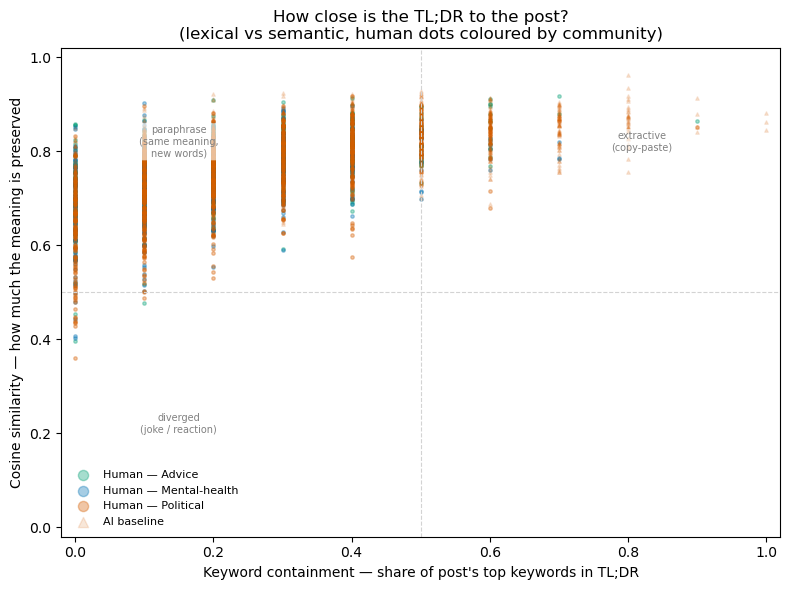

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Human dots
for bucket, grp in df.groupby("bucket"):
    ax.scatter(grp["contain_human"], grp["cosine_human"],
               s=6, alpha=0.35,
               color=COLORS_BUCKET.get(bucket, "#888888"),
               label=f"Human — {BUCKET_LABEL.get(bucket, bucket)}")

# AI reference cloud (small, faint, so it doesn't dominate)
ax.scatter(df["contain_ai"], df["cosine_ai"],
           s=6, alpha=0.15, color="#D55E00", marker="^",
           label="AI baseline")

# Quadrant annotations
for txt, xy in [("extractive\n(copy-paste)",   (0.82, 0.82)),
                ("paraphrase\n(same meaning,\nnew words)", (0.15, 0.82)),
                ("diverged\n(joke / reaction)",  (0.15, 0.22))]:
    ax.text(*xy, txt, fontsize=7, color="grey", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

ax.axvline(0.5, color="lightgrey", lw=0.8, ls="--")
ax.axhline(0.5, color="lightgrey", lw=0.8, ls="--")
ax.set_xlabel("Keyword containment — share of post's top keywords in TL;DR")
ax.set_ylabel("Cosine similarity — how much the meaning is preserved")
ax.set_title("How close is the TL;DR to the post?\n"
             "(lexical vs semantic, human dots coloured by community)")
ax.legend(fontsize=8, markerscale=3, frameon=False)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
fig.tight_layout()

fig.savefig(FIG / "05_containment_vs_cosine.png", dpi=200, bbox_inches="tight")
fig.savefig(FIG / "05_containment_vs_cosine.svg", bbox_inches="tight")
print("saved 05_containment_vs_cosine")
plt.show()

## Cell 10 — Aggregate by subreddit + overall AI baseline

In [14]:
per_sub = df.groupby("subreddit").apply(agg)

In [15]:
METRICS = {
    "first_person_density":   ("fp_human",      "fp_ai"),
    "share_question_mark":    ("q_human",        "q_ai"),
    "share_advice_words":     ("adv_human",      "adv_ai"),
    "cosine_to_post":         ("cosine_human",   "cosine_ai"),
    "keyword_containment":    ("contain_human",  "contain_ai"),
}

def agg(frame):
    out = {}
    for name, (hc, ac) in METRICS.items():
        out[(name, "human")] = frame[hc].astype(float).mean()
        out[(name, "ai")]    = frame[ac].astype(float).mean()
    return pd.Series(out)

per_sub = df.groupby("subreddit").apply(agg, include_groups=False)
overall  = agg(df).to_frame("ALL").T
table    = pd.concat([per_sub, overall])
table.columns = pd.MultiIndex.from_tuples(table.columns, names=["metric","source"])
table    = table.round(3)
table.to_csv(TAB / "human_vs_ai_by_subreddit.csv")
print("=== Human TL;DR vs AI baseline (means) ===")
with pd.option_context("display.width", 200, "display.max_columns", None):
    print(table)

TypeError: agg() got an unexpected keyword argument 'include_groups'

## Cell 11 — Figure 07: human vs AI, per community, per metric

Each panel = one metric. Each subreddit has two bars: human (dark) and AI (orange).
The dotted line is the overall AI baseline so you can see which communities
drift furthest from what a plain summary looks like.

NameError: name 'overall' is not defined

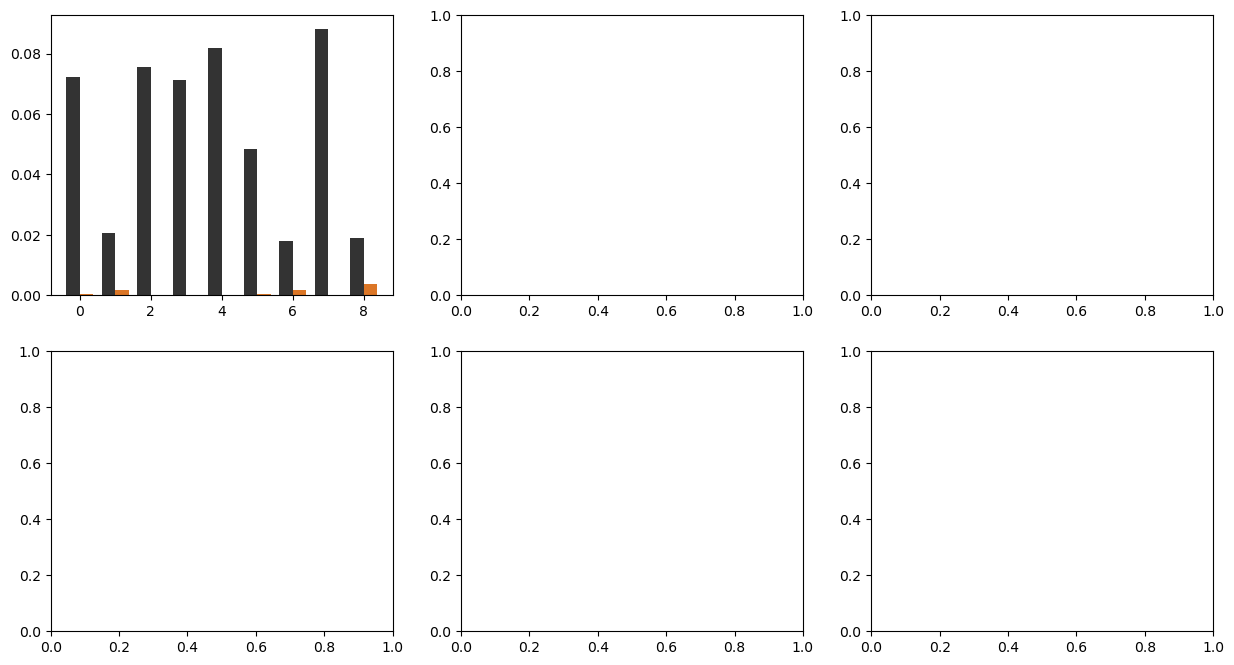

In [16]:
subs = list(per_sub.index)
x = np.arange(len(subs)); w = 0.38

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, (hc, ac)) in zip(axes.ravel(), METRICS.items()):
    h_vals = [per_sub.loc[s, (name, "human")] for s in subs]
    a_vals = [per_sub.loc[s, (name, "ai")]    for s in subs]
    ax.bar(x - w/2, h_vals, w, label="human TL;DR", color=COLORS_SRC["human"])
    ax.bar(x + w/2, a_vals, w, label="AI baseline",  color=COLORS_SRC["ai"], alpha=0.85)
    ax.axhline(overall[(name, "ai")].iloc[0],
               color=COLORS_SRC["ai"], lw=0.8, ls=":")
    ax.set_title(name.replace("_", " "), fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"r/{s}" for s in subs], rotation=45, ha="right", fontsize=7)
    ax.spines[["top","right"]].set_visible(False)

axes.ravel()[0].legend(frameon=False, fontsize=8)
for ax in axes.ravel()[len(METRICS):]:
    ax.set_visible(False)
fig.suptitle(
    "Human TL;DR vs. AI baseline, by community\n"
    "(dotted line = overall AI baseline mean)",
    fontweight="bold"
)
fig.tight_layout()
fig.savefig(FIG / "07_human_vs_ai_by_subreddit.png", dpi=200, bbox_inches="tight")
fig.savefig(FIG / "07_human_vs_ai_by_subreddit.svg", bbox_inches="tight")
print("saved 07_human_vs_ai_by_subreddit")
plt.show()

## Cell 12 — Copy figures to website folder + print summary

In [ ]:
import shutil

for name in ["05_containment_vs_cosine.png", "07_human_vs_ai_by_subreddit.png"]:
    src = FIG / name
    dst = WEB / name
    if src.exists():
        shutil.copy2(src, dst)
        print(f"Copied to website: {dst}")
    else:
        print(f"WARNING: {src} not found")

print("\n✓ All done. Figures + table written:")
print(f"  {FIG}/05_containment_vs_cosine.png")
print(f"  {FIG}/07_human_vs_ai_by_subreddit.png")
print(f"  {TAB}/human_vs_ai_by_subreddit.csv")
print(f"  {ROOT.parent/'figures'}/  (website copies)")
print("\nNext: git add + commit + push from your local machine to update GitHub Pages.")